# 11 — Scale-in baseline: 2024 / 2025 / 2026 + all three combined

Lookahead-free entry: add a SHORT tranche on each trigger of a pump cluster
(ramped — later adds bigger), total notional capped = one position; 3% stop on
the average entry armed AFTER the cluster stops firing; 4h time-exit.

**Universe:** a single fixed set of **140 Bybit USDT-perp alts** with full
1m coverage 2024-01..2026-04 (NOT a curated pumpy list, NOT survivorship-cleaned
beyond 'has data'). Fixed across all years so cross-year differences are about
the market, not the symbol list.

This is the honest starting baseline to improve from.

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *
import heapq

d = np.load('_out/scalein_3y.npz')
ts, pf, offf, ps, offs, ntr = d['ts'], d['pf'], d['offf'], d['ps'], d['offs'], d['ntr']
year = pd.to_datetime(ts).year
COST = 0.0015
print(f'total events: {len(ts)}   avg tranches/cluster: {ntr.mean():.1f}')
print(f"{'period':<8}{'events':>8}{'first net':>12}{'scale net':>12}{'scale win':>11}{'q10':>8}")
for y in [2024, 2025, 2026]:
    m = year == y
    fn, sn = (pf[m] - COST), (ps[m] - COST)
    print(f'{y:<8}{m.sum():>8}{fn.mean()*100:>+11.2f}%{sn.mean()*100:>+11.2f}%'
          f'{(sn>0).mean()*100:>10.0f}%{np.quantile(sn,.1)*100:>+7.1f}%')
alln = ps - COST
print(f"{'ALL':<8}{len(ts):>8}{(pf-COST).mean()*100:>+11.2f}%{alln.mean()*100:>+11.2f}%"
      f"{(alln>0).mean()*100:>10.0f}%{np.quantile(alln,.1)*100:>+7.1f}%")

total events: 7568   avg tranches/cluster: 7.7
period    events   first net   scale net  scale win     q10
2024        3828      -0.71%      +0.37%        48%   -3.9%
2025        2767      -0.77%      +0.81%        52%   -3.9%
2026         973      -0.72%      +1.13%        51%   -3.9%
ALL         7568      -0.74%      +0.63%        50%   -3.9%


In [2]:
CAPITAL, SIZE = 1000.0, 20.0
def portfolio(pnl_net, off, tstamps):
    emin = ((tstamps - tstamps.min()) // (60 * 10**9)).astype(int)
    xmin = emin + off
    order = np.argsort(emin)
    eq = CAPITAL; comm = 0.0; op = []; taken = 0; maxc = 0
    ct, ce = [], []
    for k in order:
        now = emin[k]
        while op and op[0][0] <= now:
            _, dd = heapq.heappop(op); eq += dd; comm -= SIZE; ct.append(now); ce.append(eq)
        if eq - comm >= SIZE:
            heapq.heappush(op, (xmin[k], SIZE * pnl_net[k])); comm += SIZE; taken += 1
            maxc = max(maxc, len(op))
    while op:
        t, dd = heapq.heappop(op); eq += dd; comm -= SIZE; ct.append(t); ce.append(eq)
    s = pd.Series(ce, index=pd.to_datetime(tstamps.min()) + pd.to_timedelta(ct, 'm')).sort_index()
    mdd = (s / s.cummax() - 1).min() * 100
    return eq, mdd, taken, s

print('Per-year portfolio ($1000 reset each year, scale-in):')
print(f"{'year':<8}{'return':>9}{'maxDD':>8}{'ann.':>8}{'taken':>7}")
months = {2024: 12, 2025: 12, 2026: 4}
for y in [2024, 2025, 2026]:
    m = year == y
    eq, mdd, tk, _ = portfolio(ps[m] - COST, offs[m], ts[m])
    ann = ((eq / CAPITAL) ** (12 / months[y]) - 1) * 100
    print(f'{y:<8}{(eq/CAPITAL-1)*100:>+8.0f}%{mdd:>7.1f}%{ann:>+7.0f}%{tk:>7}')

Per-year portfolio ($1000 reset each year, scale-in):
year       return   maxDD    ann.  taken
2024         +49%   -7.2%    +49%   3443
2025         +59%   -6.1%    +59%   2539
2026         +28%   -3.1%   +108%    877


## All three years combined — one continuous $1000 account

combined span: 27.9 months (2024-01-01 -> 2026-04-30)
SCALE-IN:      $2,256  (+126%)  maxDD -7.2%  ann +42%  taken 7034
first-trigger: $519  (-48%)  maxDD -48.4%


[saved] notebooks\pump\_out\11_scalein_3y_equity.png


WindowsPath('C:/projects/researchlab/notebooks/pump/_out/11_scalein_3y_equity.png')

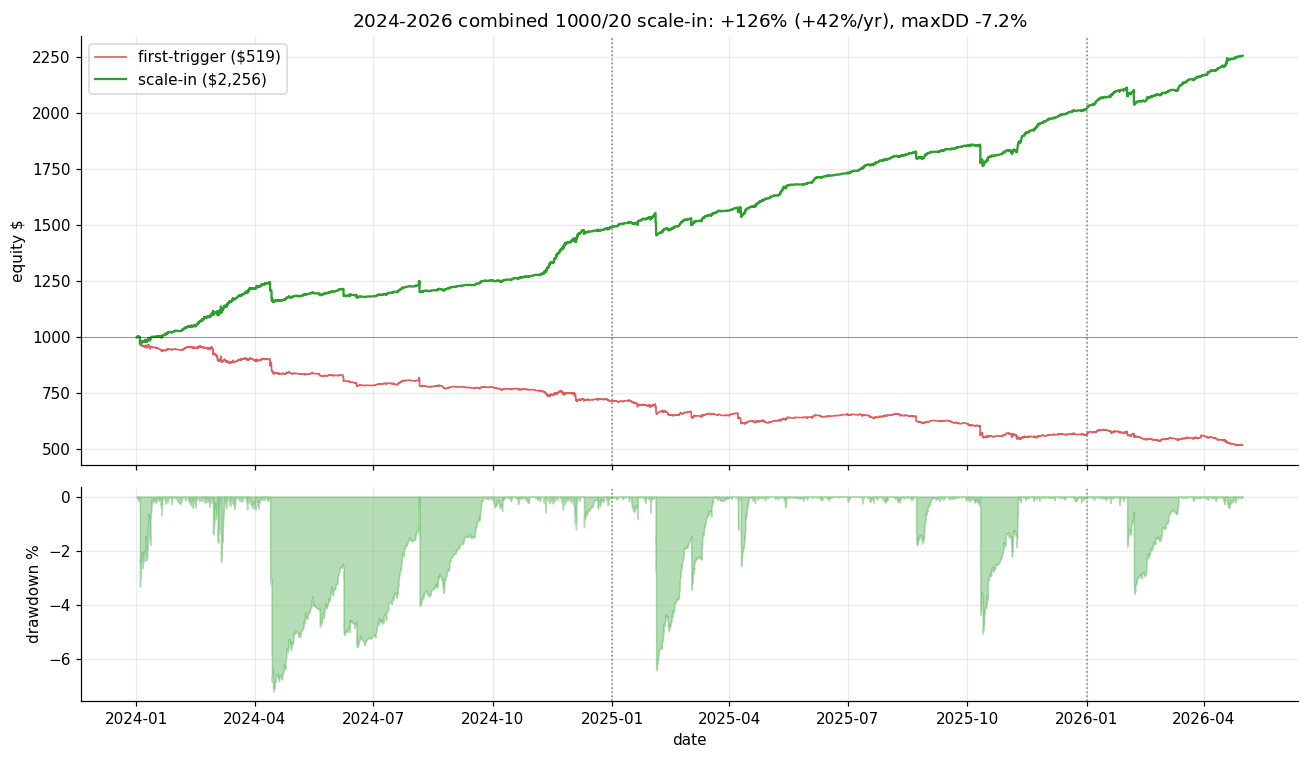

In [3]:
eq, mdd, tk, curve = portfolio(ps - COST, offs, ts)
eqf, mddf, _, curvef = portfolio(pf - COST, offf, ts)
span_months = (pd.to_datetime(ts.max()) - pd.to_datetime(ts.min())).days / 30.44
ann = ((eq / CAPITAL) ** (12 / span_months) - 1) * 100
print(f'combined span: {span_months:.1f} months ({pd.to_datetime(ts.min()).date()} -> {pd.to_datetime(ts.max()).date()})')
print(f'SCALE-IN:      ${eq:,.0f}  ({(eq/CAPITAL-1)*100:+.0f}%)  maxDD {mdd:.1f}%  ann {ann:+.0f}%  taken {tk}')
print(f'first-trigger: ${eqf:,.0f}  ({(eqf/CAPITAL-1)*100:+.0f}%)  maxDD {mddf:.1f}%')

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios':[2,1]})
a1.plot(curvef.index, curvef.values, lw=1.1, color='tab:red', alpha=0.75, label=f'first-trigger (${eqf:,.0f})')
a1.plot(curve.index, curve.values, lw=1.5, color='tab:green', label=f'scale-in (${eq:,.0f})')
a1.axhline(CAPITAL, color='k', lw=0.6, alpha=0.4)
for yb in ['2025-01-01', '2026-01-01']:
    a1.axvline(pd.Timestamp(yb), color='gray', ls=':', lw=1)
a1.set_ylabel('equity $'); a1.legend(loc='upper left')
a1.set_title(f'2024-2026 combined $1000/$20 scale-in: {(eq/CAPITAL-1)*100:+.0f}% ({ann:+.0f}%/yr), maxDD {mdd:.1f}%')
dd = (curve / curve.cummax() - 1) * 100
a2.fill_between(curve.index, dd.values, 0, color='tab:green', alpha=0.35)
for yb in ['2025-01-01', '2026-01-01']:
    a2.axvline(pd.Timestamp(yb), color='gray', ls=':', lw=1)
a2.set_ylabel('drawdown %'); a2.set_xlabel('date')
show('11_scalein_3y_equity')

In [4]:
# monthly net per-trade across the whole span (scale-in)
m = pd.DataFrame({'pnl': (ps - COST) * 100, 't': pd.to_datetime(ts)})
m['month'] = m['t'].dt.to_period('M')
g = m.groupby('month')['pnl'].agg(['mean', 'count'])
print(f"profitable months: {(g['mean']>0).sum()} / {len(g)}   (worst {g['mean'].min():.2f}%, best {g['mean'].max():.2f}%)")
print(g.round(2).to_string())

profitable months: 21 / 28   (worst -0.75%, best 2.52%)
         mean  count
month               
2024-01 -0.34    453
2024-02  0.94    400
2024-03  0.41    699
2024-04 -0.68    414
2024-05  0.79    133
2024-06 -0.75    217
2024-07  2.00    117
2024-08 -0.74    312
2024-09  1.84     80
2024-10  0.86    122
2024-11  1.90    414
2024-12  0.48    467
2025-01  1.03    230
2025-02 -0.71    424
2025-03  0.80    233
2025-04  0.74    363
2025-05  2.45    141
2025-06  2.52     85
2025-07  1.96    164
2025-08  0.66    199
2025-09  1.66     97
2025-10 -0.67    397
2025-11  2.23    306
2025-12  2.00    128
2026-01  0.95    300
2026-02 -0.06    304
2026-03  2.40    168
2026-04  2.14    201
